<a href="https://colab.research.google.com/github/yossefgamal579-cpu/Word-Teacher/blob/main/yossefandlama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

In [ ]:
!unzip /content/titanic.zip

Archive:  /content/titanic.zip
replace gender_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

In [ ]:
train_data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
train_data.shape

(891, 12)

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
train_data['Age']=train_data['Age'].fillna(train_data['Age'].median())

In [ ]:
train_data = train_data.drop(columns='Cabin', axis=1)

In [ ]:
print(train_data['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [ ]:
train_data['Embarked']= train_data['Embarked'].fillna('S')

In [ ]:
print(train_data.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
train_data['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
sns.set()

<Axes: xlabel='Survived', ylabel='count'>

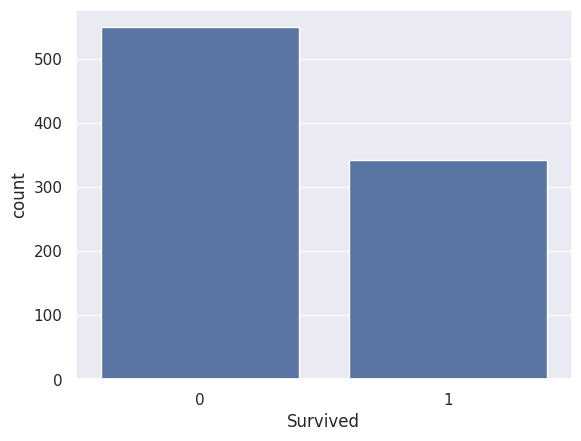

In [ ]:
sns.countplot(x='Survived', data=train_data)

In [ ]:
train_data['Sex'].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Sex', ylabel='count'>

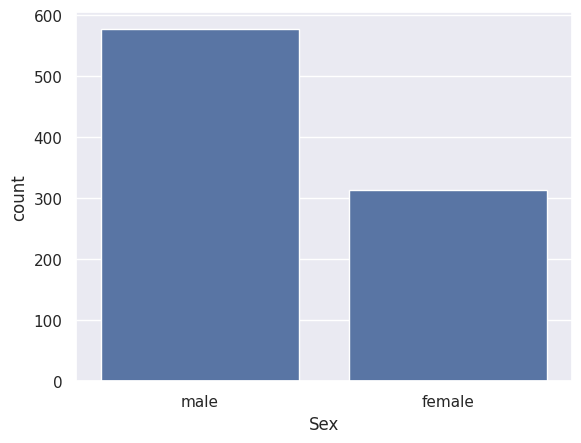

In [ ]:
sns.countplot(x='Sex', data=train_data)

<Axes: xlabel='Sex', ylabel='count'>

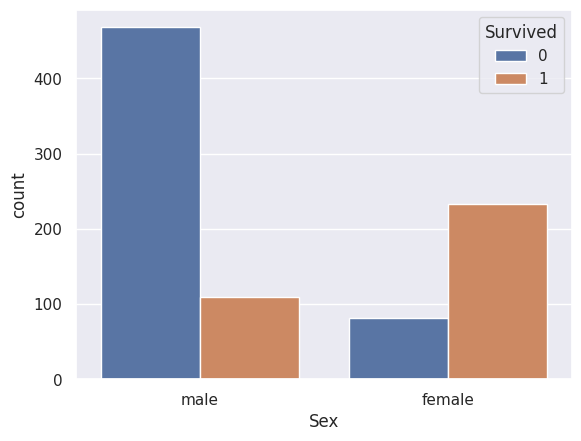

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=train_data)

In [ ]:
train_data['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


<Axes: xlabel='Pclass', ylabel='count'>

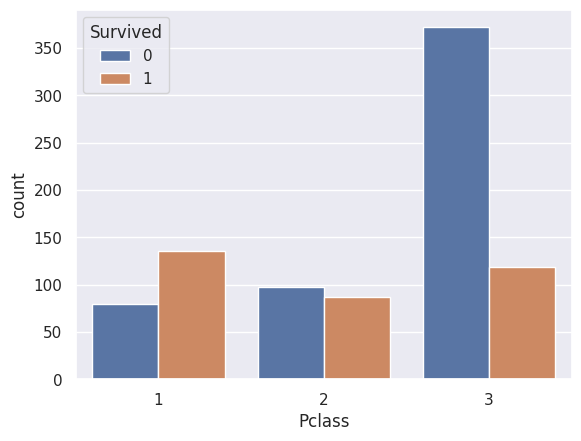

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=train_data)

Encoding

In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
train_data.replace({'Sex':{'male':0, 'female':1}, 'Embarked':{'S':0, 'C' :1, 'Q' :2}}, inplace=True)

/tmp/ipykernel_162/1401721902.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data.replace({'Sex':{'male':0, 'female':1}, 'Embarked':{'S':0, 'C' :1, 'Q' :2}}, inplace=True)


In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


In [ ]:
x= train_data.drop(columns=['Survived','PassengerId','Name','Ticket'],axis=1)
y=train_data['Survived']

In [ ]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


In [ ]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


Modeling

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

NameError: name 'LogisticRegression' is not defined

In [ ]:
model.fit(x,y)

In [ ]:
train_predict = model.predict(x)
accuracy= accuracy_score(y, train_predict)
print(f"accuracy: {accuracy}")

In [ ]:
print(classification_report(y, train_predict))

In [ ]:
Model = DecisionTreeClassifier()

In [ ]:
Model.fit(x,y)

In [ ]:
tree_train = Model.predict(x)
accuracy = accuracy_score(y, tree_train)
print(f"accuracy: {accuracy}")

In [ ]:
print(classification_report(y, tree_train))

In [ ]:
test_data.head()

In [ ]:
test_data.info()

In [ ]:
test_data['Age']=test_data['Age'].fillna(test_data['Age'].median())

In [ ]:
test_data['Fare']=test_data['Fare'].fillna(test_data['Fare'].median())

In [ ]:
print(test_data.isnull().sum())

In [ ]:
test_data= test_data.drop(columns=['PassengerId','Name','Ticket','Capin'], axis=1)

In [ ]:
test_data.replace({'sex':0,'female':1}, 'Embarked':{'S':0,'C':1,'Q':2 }, inplace=True)

In [ ]:
test_data.head()

Infrence

In [ ]:
label_map = {
    0: "Did not Survive",
    1: "Survived"
}

# Reverse mapping (text → number)
Sex_map = {
    "male": 0,
    "female": 1
}

Embarked_map = {
    "cherbourg": 1,
    "queenstown": 2,
    "southampton": 0
}

# Collect user input
Pclass = int(input("Enter class (1, 2, 3): "))
Sex_input = input("Enter sex (Male/Female): ").lower()
Embarked_input = input("Enter embarked (Cherbourg/Queenstown/Southampton): ").lower()
Age = float(input("Enter age: "))
SibSp = float(input("Enter Sibling/Spouse count: "))
Parch = float(input("Enter Parent/Child count: "))
Fare = float(input("Enter fare: "))

# Convert text to numeric
Sex = Sex_map.get(Sex_input)
Embarked = Embarked_map.get(Embarked_input)

# Check for invalid input
if Sex is None:
    print("Invalid sex entered!")
    exit()

if Embarked is None:
    print("Invalid embarked location entered!")
    exit()

# Prepare input for model
input_data = np.array([[Pclass, Sex, Age, SibSp, Parch, Fare, Embarked]])

# Make prediction
prediction = Model.predict(input_data)[0]

# Print results
print("\n🚢 Titanic Survival Prediction:")
print("--------------------------------")
print(f"Class: {Pclass}")
print(f"Sex: {Sex_input}")
print(f"Age: {Age}")
print(f"SibSp: {SibSp}")
print(f"Parch: {Parch}")
print(f"Fare: {Fare}")
print(f"Embarked: {Embarked_input}")
print("--------------------------------")
print(f"Prediction: {label_map[prediction]}")